# Forest plots

Source notebook for figures 2–4

PTCy meta-analysis collaboration

The figures in the article are drawn from two ingredients that come from different places:

- **the study rows** — raw per-study odds ratios with Wald 95% CIs, computed here directly from the extracted event counts in `data/analytic/`, with a 0·5 continuity correction applied only to studies with a zero cell;
- **the pooled row** — the Bayesian random-effects posterior (model M1), taken from the exported summaries in `data/models/Table2_setB.csv`.

The study rows are *not* per-study Bayesian estimates. M1 has a single shared treatment effect with a random intercept for study-level baseline risk only, so individual studies have no treatment-effect posterior of their own.

In [ ]:
library(dplyr)



Attaching package: 'dplyr'

The following objects are masked from 'package:stats':

    filter, lag

The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union

In [ ]:

# Wald log-OR and CI from a 2x2 table, with 0.5 added only where a cell is zero.
study_or <- function(d) {
  d |>
    mutate(zero = ptcy_e == 0 | comp_e == 0 |
                  ptcy_e == ptcy_n | comp_e == comp_n,
           a = ptcy_e + 0.5 * zero, b = ptcy_n - ptcy_e + 0.5 * zero,
           c = comp_e + 0.5 * zero, d2 = comp_n - comp_e + 0.5 * zero,
           yi = log((a / b) / (c / d2)),
           sei = sqrt(1/a + 1/b + 1/c + 1/d2),
           or = exp(yi), lo = exp(yi - 1.96 * sei), hi = exp(yi + 1.96 * sei)) |>
    filter(is.finite(or), is.finite(lo), is.finite(hi))
}

# The adopted analysis is Set B: one publication per cohort per outcome. Only the
# outcomes affected by deduplication were refitted, so data/models/ is a partial overlay
# -- prefer the Set B dataset for a slug, and fall back to the full analytic dataset for
# the outcomes deduplication left untouched.
resolve_data <- function(analytic_file, slug) {
  setb <- here("data", "models", paste0("data_", slug, ".csv"))
  if (file.exists(setb)) return(setb)
  here("data", "analytic", analytic_file)
}

forest <- function(analytic_file, slug, title, subtitle = NULL) {
  f <- resolve_data(analytic_file, slug)
  if (!file.exists(f)) { message("missing: ", analytic_file); return(invisible(NULL)) }
  message("  ", slug, " <- ", sub("^.*/", "", f))

  es <- read_csv(f, show_col_types = FALSE) |>
    study_or() |>
    left_join(studies, by = "study_id") |>
    mutate(slab = sprintf("%s (%s)", first_author, pub_year))
  # multi-arm studies contribute more than one row: keep the labels distinct
  es$slab <- make.unique(es$slab, sep = " – ")
  es <- es |> arrange(yi) |> mutate(slab = factor(slab, levels = slab))

  p <- pooled |> filter(slug == !!slug, model == "m1")
  stopifnot(nrow(p) == 1)

  pd <- bind_rows(
    es |> transmute(slab = as.character(slab), or, lo, hi, pooled = FALSE),
    tibble(slab = "Bayesian pooled (M1)", or = p$or_median,
           lo = p$ci_low, hi = p$ci_high, pooled = TRUE))
  pd$slab <- factor(pd$slab, levels = c("Bayesian pooled (M1)", levels(es$slab)))

  ggplot(pd, aes(or, slab)) +
    geom_vline(xintercept = 1, linetype = "dashed",
               colour = lancet_grey, linewidth = .35) +
    # study rows: crimson squares, the journal's forest-plot marker
    geom_pointrange(data = filter(pd, !pooled), aes(xmin = lo, xmax = hi),
                    shape = 15, size = .3, linewidth = .4, colour = lancet_red) +
    # pooled row: a filled diamond, larger and in the same crimson
    geom_pointrange(data = filter(pd, pooled), aes(xmin = lo, xmax = hi),
                    shape = 18, size = .95, linewidth = .8, colour = lancet_red) +
    scale_x_log10() +
    labs(x = "Odds ratio (log scale)", y = NULL, title = title,
         subtitle = subtitle %||% sprintf("k = %d, N = %s, τ = %.2f",
                                          p$k, format(p$n_total, big.mark = " "), p$tau),
         caption = "Study rows: raw per-study OR with Wald 95% CI. Diamond: Bayesian posterior median with 95% CrI.") +
    theme_forest() +
    theme(axis.text.y = element_text(
      face = ifelse(levels(pd$slab) == "Bayesian pooled (M1)", "bold", "plain"),
      size = rel(.85)))
}

`%||%` <- function(a, b) if (is.null(a)) b else a


## Figure 2 — overall survival (comparison 1)

  c1_os <- data_c1_os.csv

ℹ Results may be unexpected or may change in future versions of ggplot2.

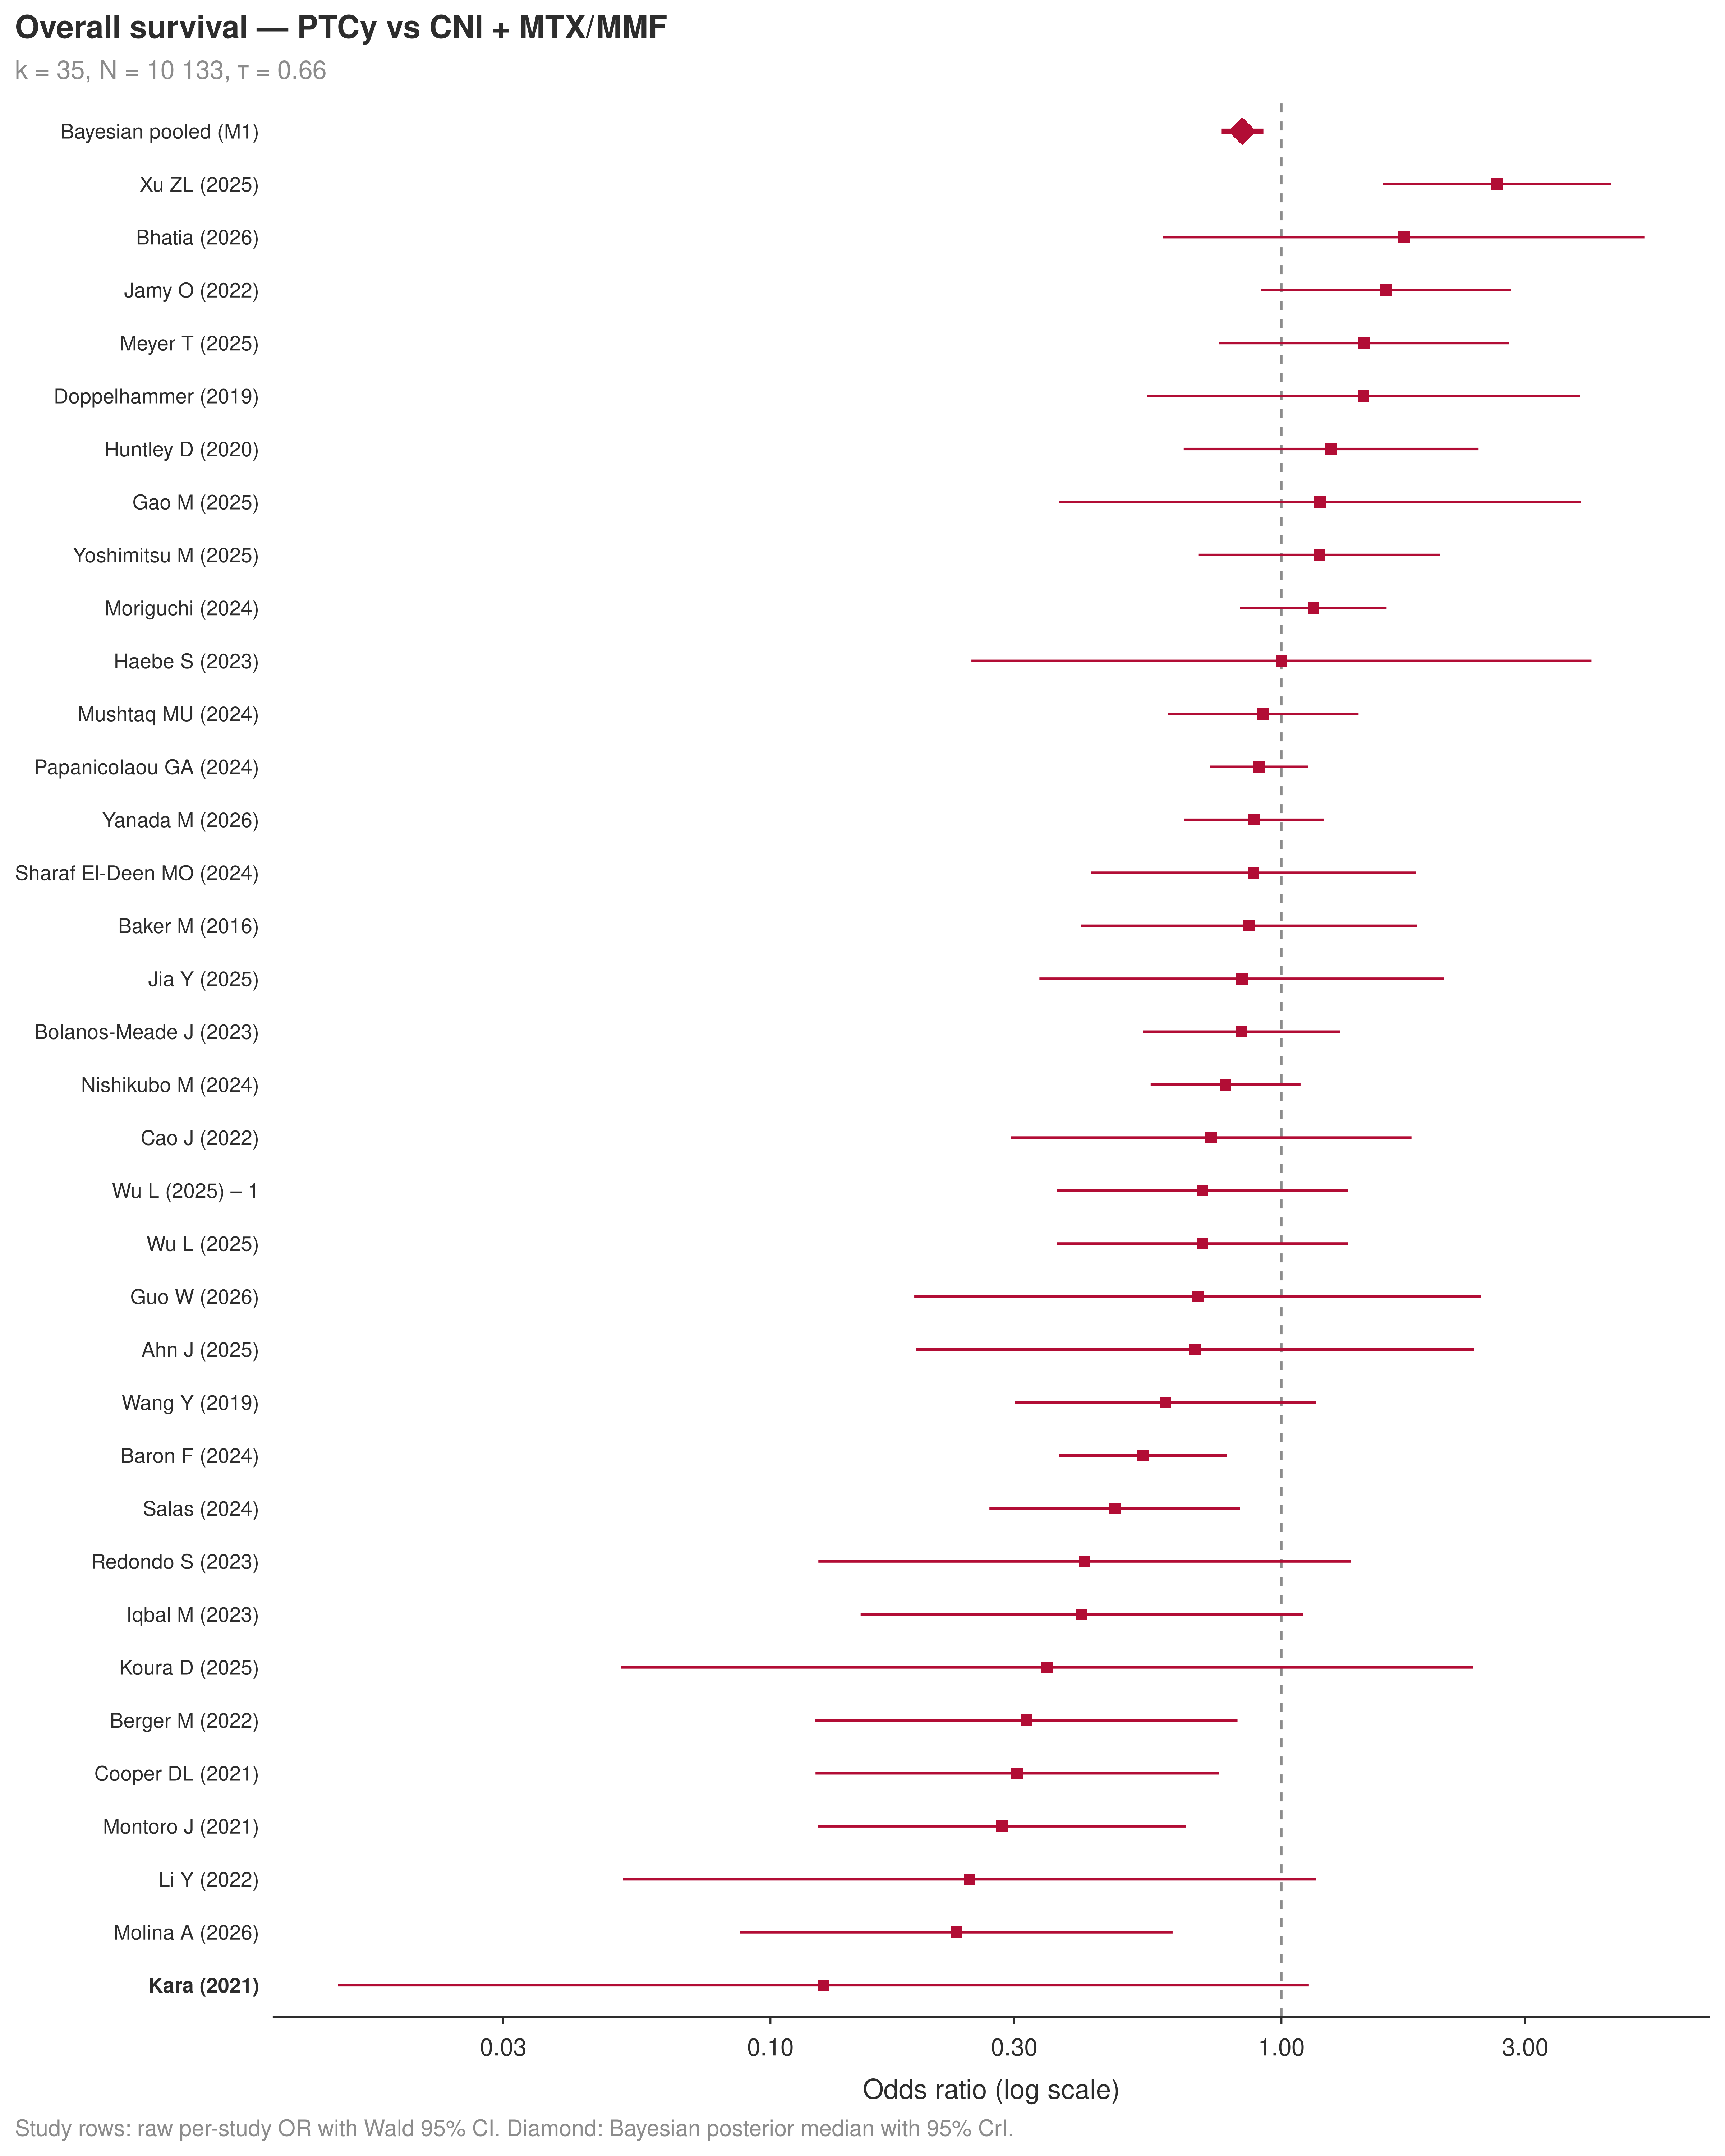

In [ ]:
forest("C1_overall_mortality_OS_event.csv", "c1_os",
       "Overall survival — PTCy vs CNI + MTX/MMF")


## Figure 3 — CMV reactivation

  c1_cmv <- C1_CMV_any_reactivation.csv

ℹ Results may be unexpected or may change in future versions of ggplot2.

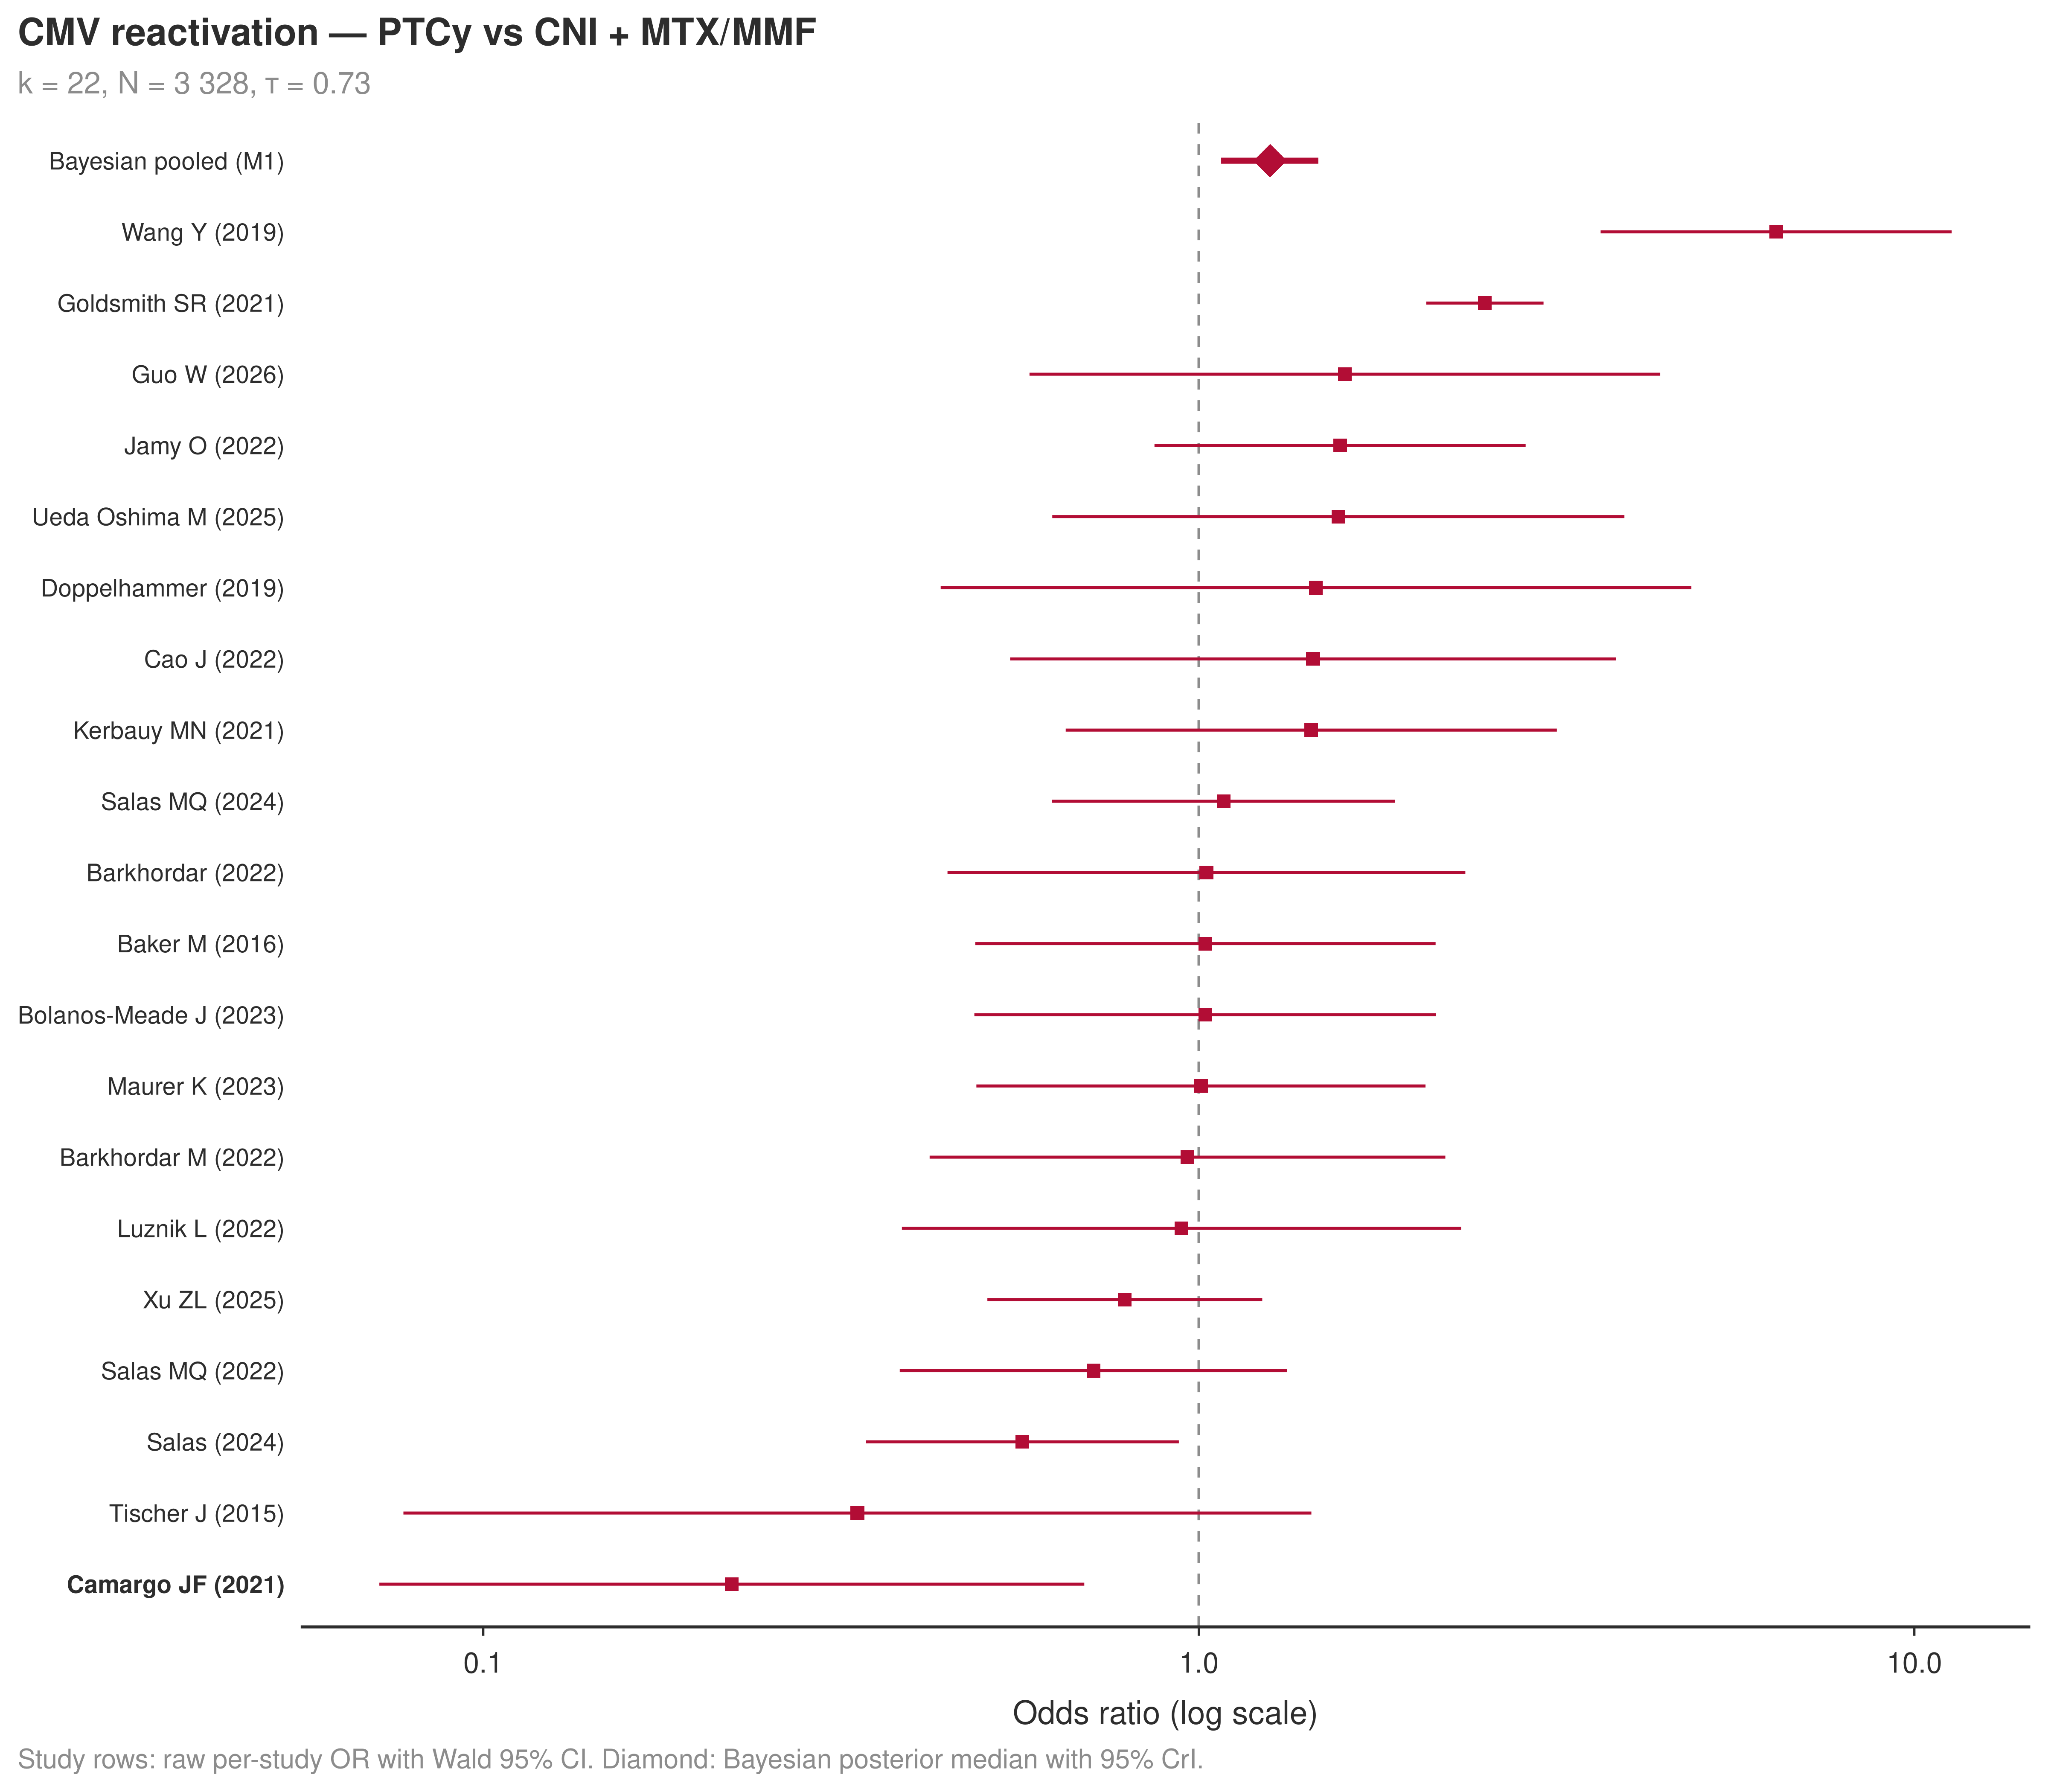

In [ ]:
forest("C1_CMV_any_reactivation.csv", "c1_cmv",
       "CMV reactivation — PTCy vs CNI + MTX/MMF")


  c2_cmv <- data_c2_cmv.csv

ℹ Results may be unexpected or may change in future versions of ggplot2.

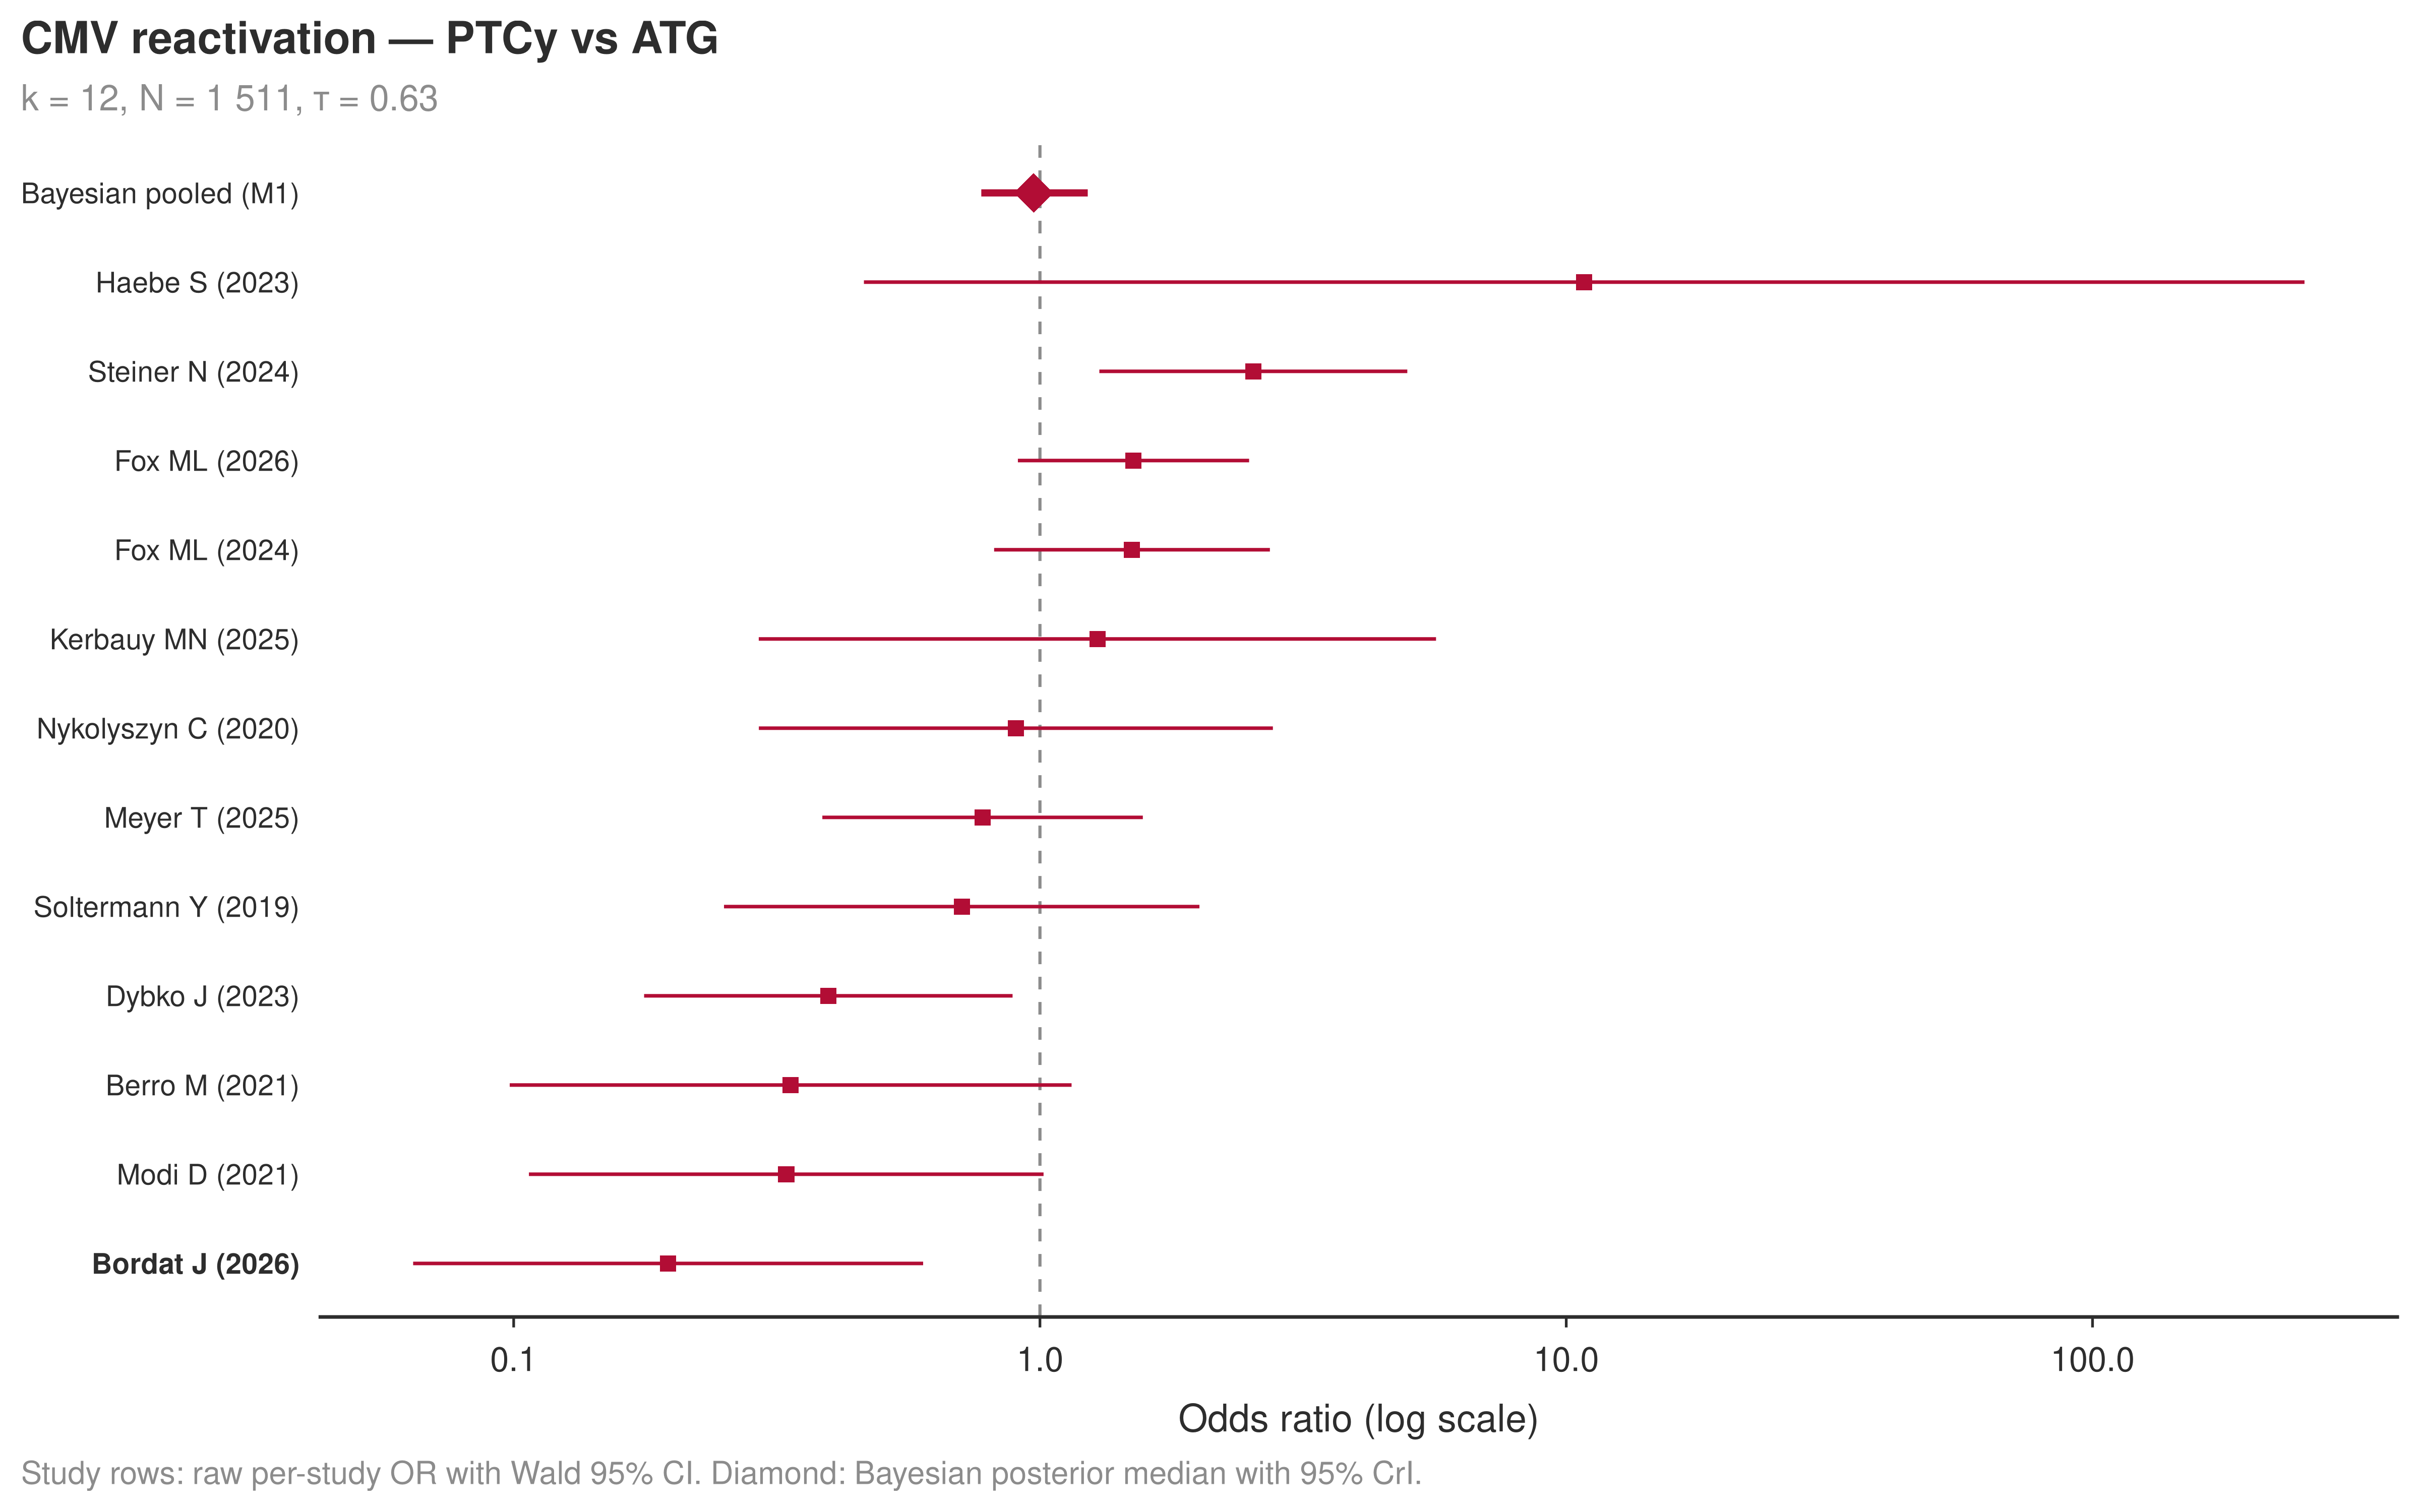

In [ ]:
forest("C2_CMV_any_reactivation.csv", "c2_cmv",
       "CMV reactivation — PTCy vs ATG")


## Figure 4 — bacterial, fungal, and BK viral infection

  c1_bsi <- C1_BSI_any_pathogen.csv

ℹ Results may be unexpected or may change in future versions of ggplot2.

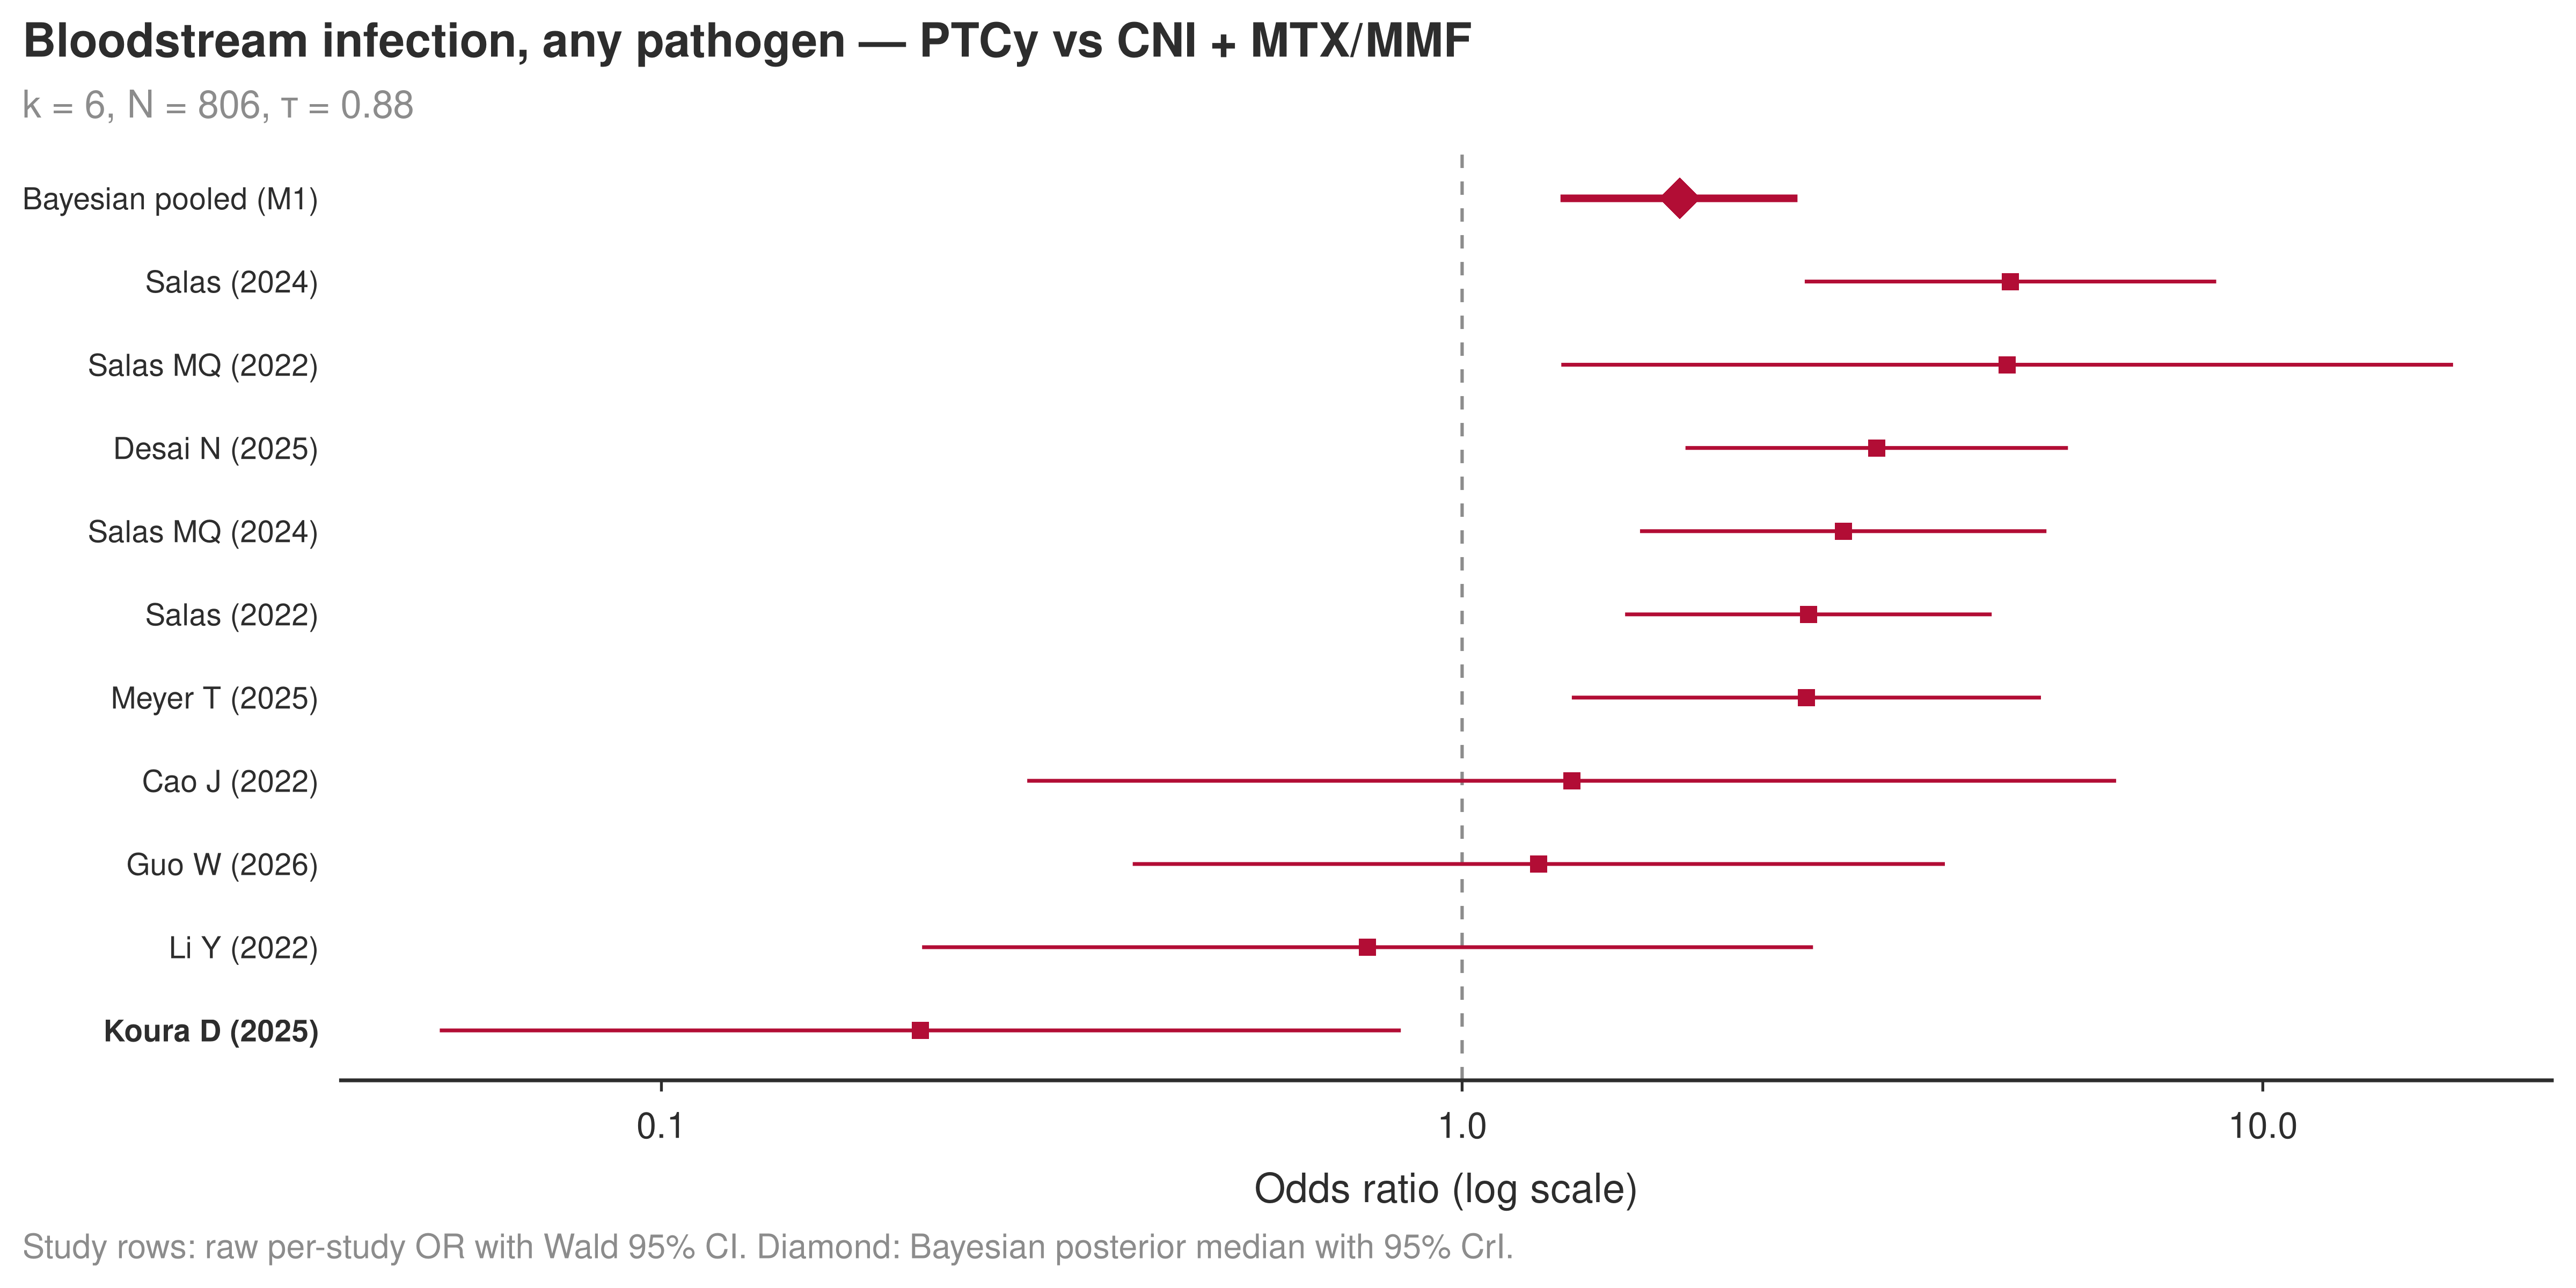

In [ ]:
forest("C1_BSI_any_pathogen.csv", "c1_bsi",
       "Bloodstream infection, any pathogen — PTCy vs CNI + MTX/MMF")


  c1_ifi_any <- C1_IFI_any_EORTC_MSG_proven_probable_combined.csv

ℹ Results may be unexpected or may change in future versions of ggplot2.

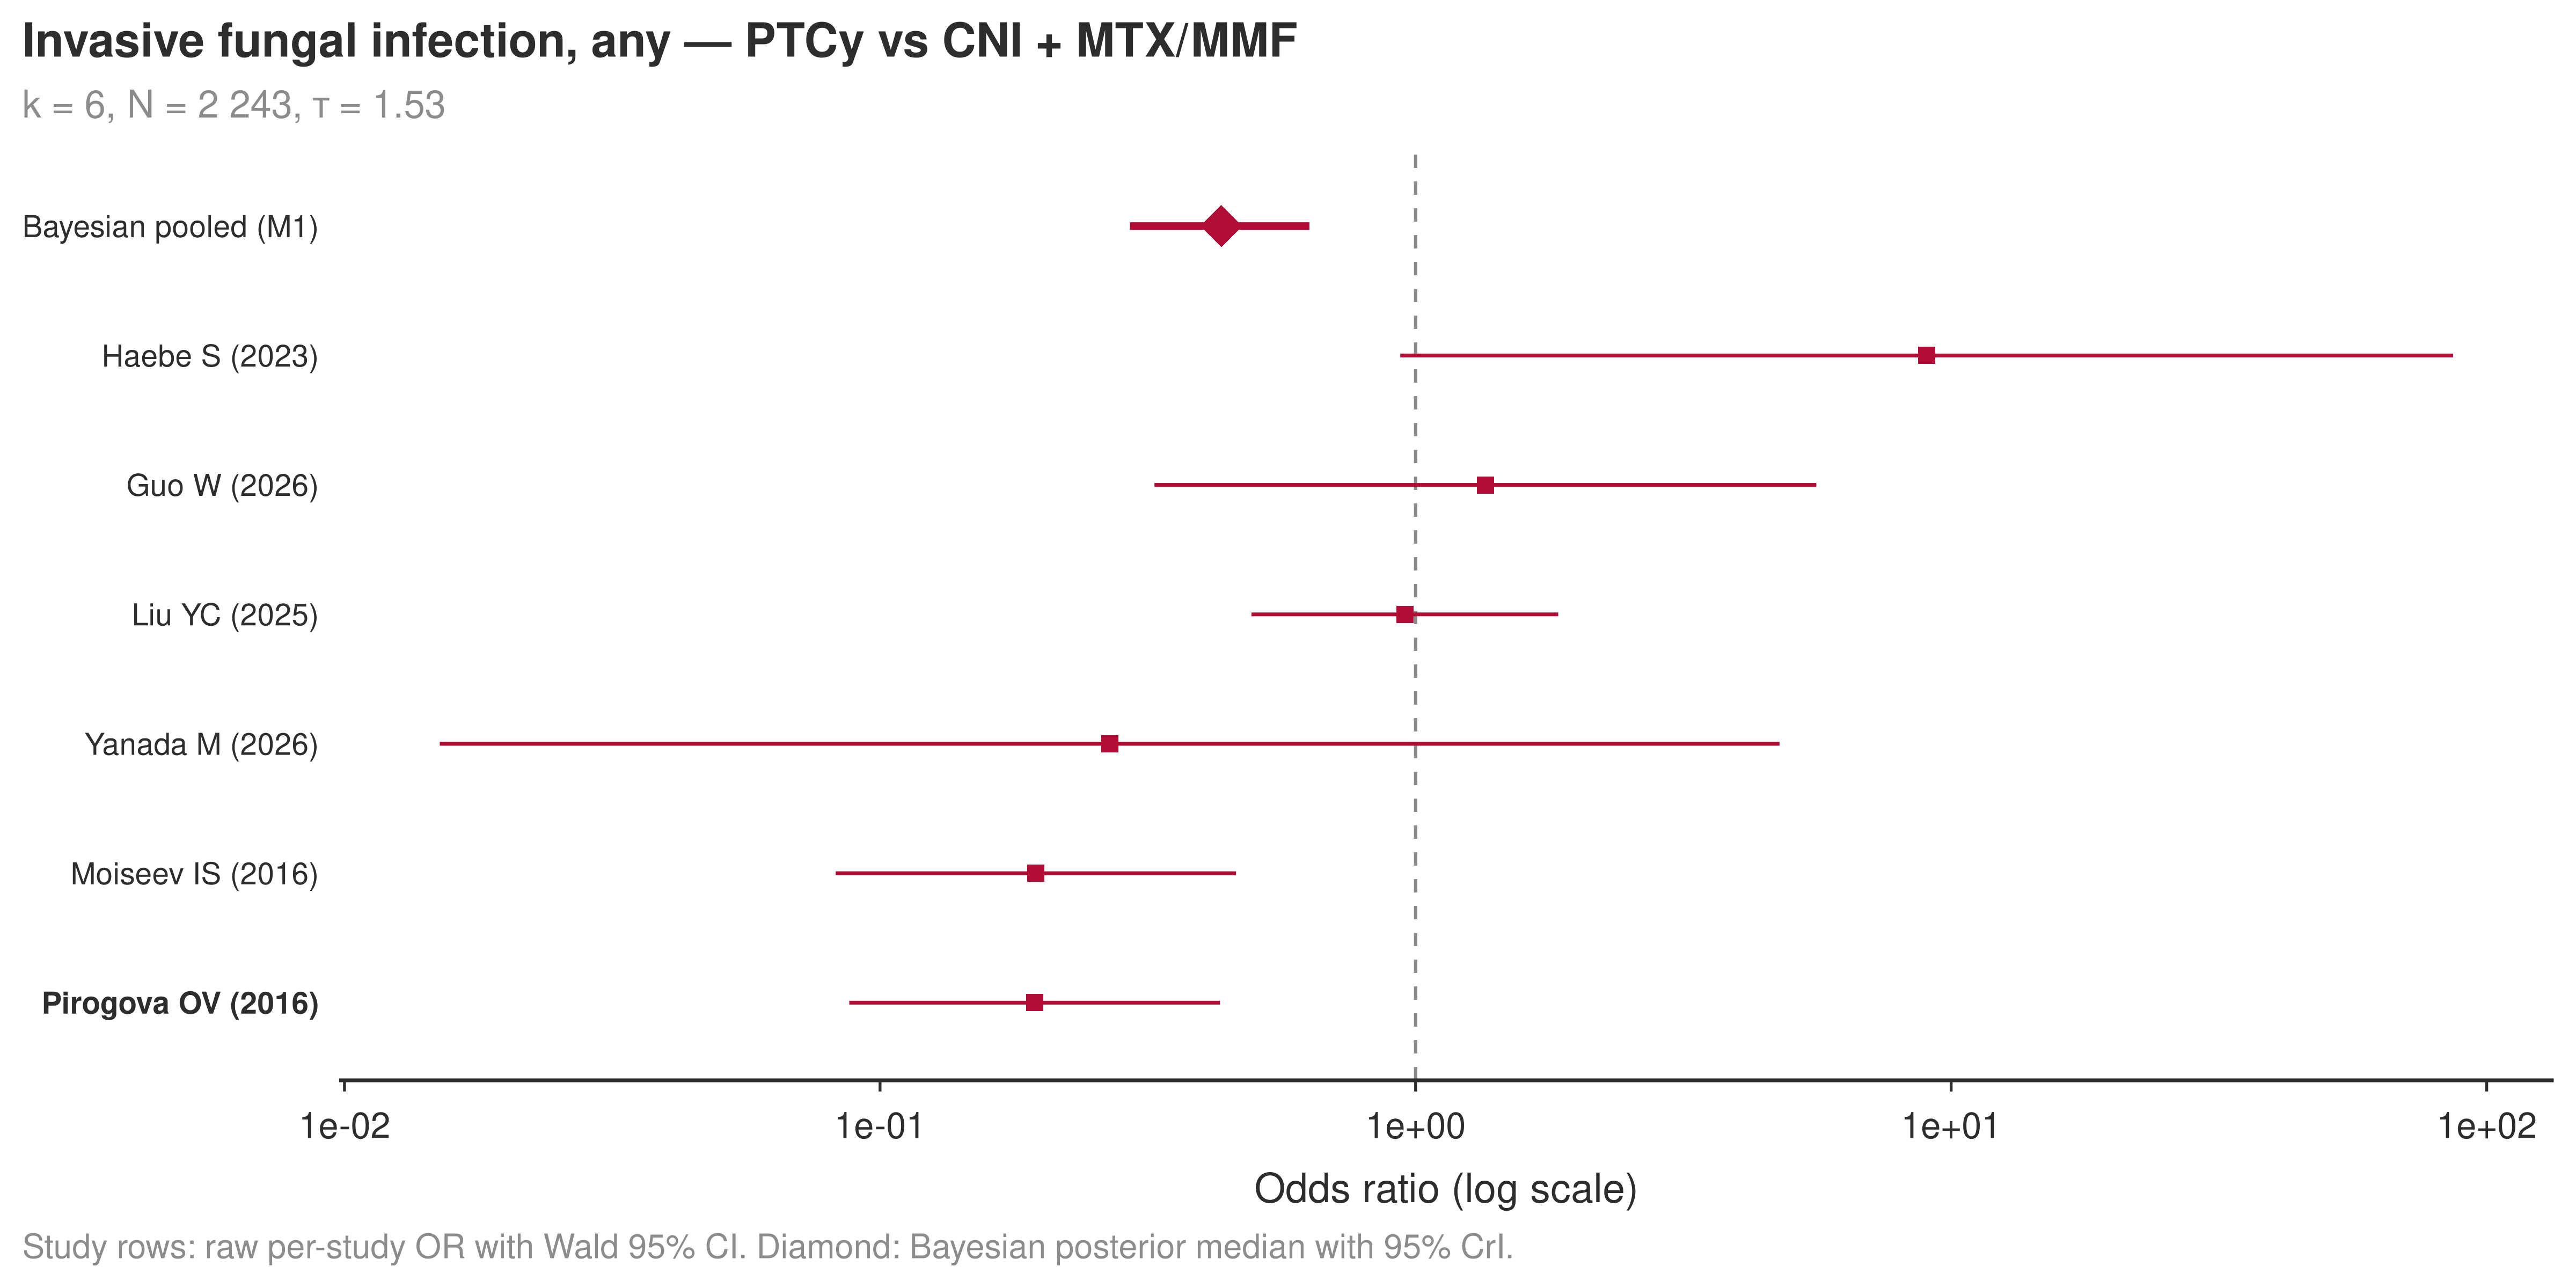

In [ ]:
forest("C1_IFI_any_EORTC_MSG_proven_probable_combined.csv", "c1_ifi_any",
       "Invasive fungal infection, any — PTCy vs CNI + MTX/MMF")


Panel C of figure 4 in the article is BK virus reactivation. The BK analytic dataset was not part of the `02_extraction/analytic/` export in the analysis repository, so it is not reproduced here — the pooled estimate is still carried in table 2 (`c1_bk`, k = 11, OR 2·48 \[1·82–3·38\]). To add the panel, export the BK pairs from `outcomes.csv` into `data/analytic/C1_BK_virus_reactivation.csv` with the same columns as the other files and call `forest()` on it.

## Acute GVHD grade II–IV

  c1_agvhd <- C1_aGVHD_grade_II_IV.csv

ℹ Results may be unexpected or may change in future versions of ggplot2.

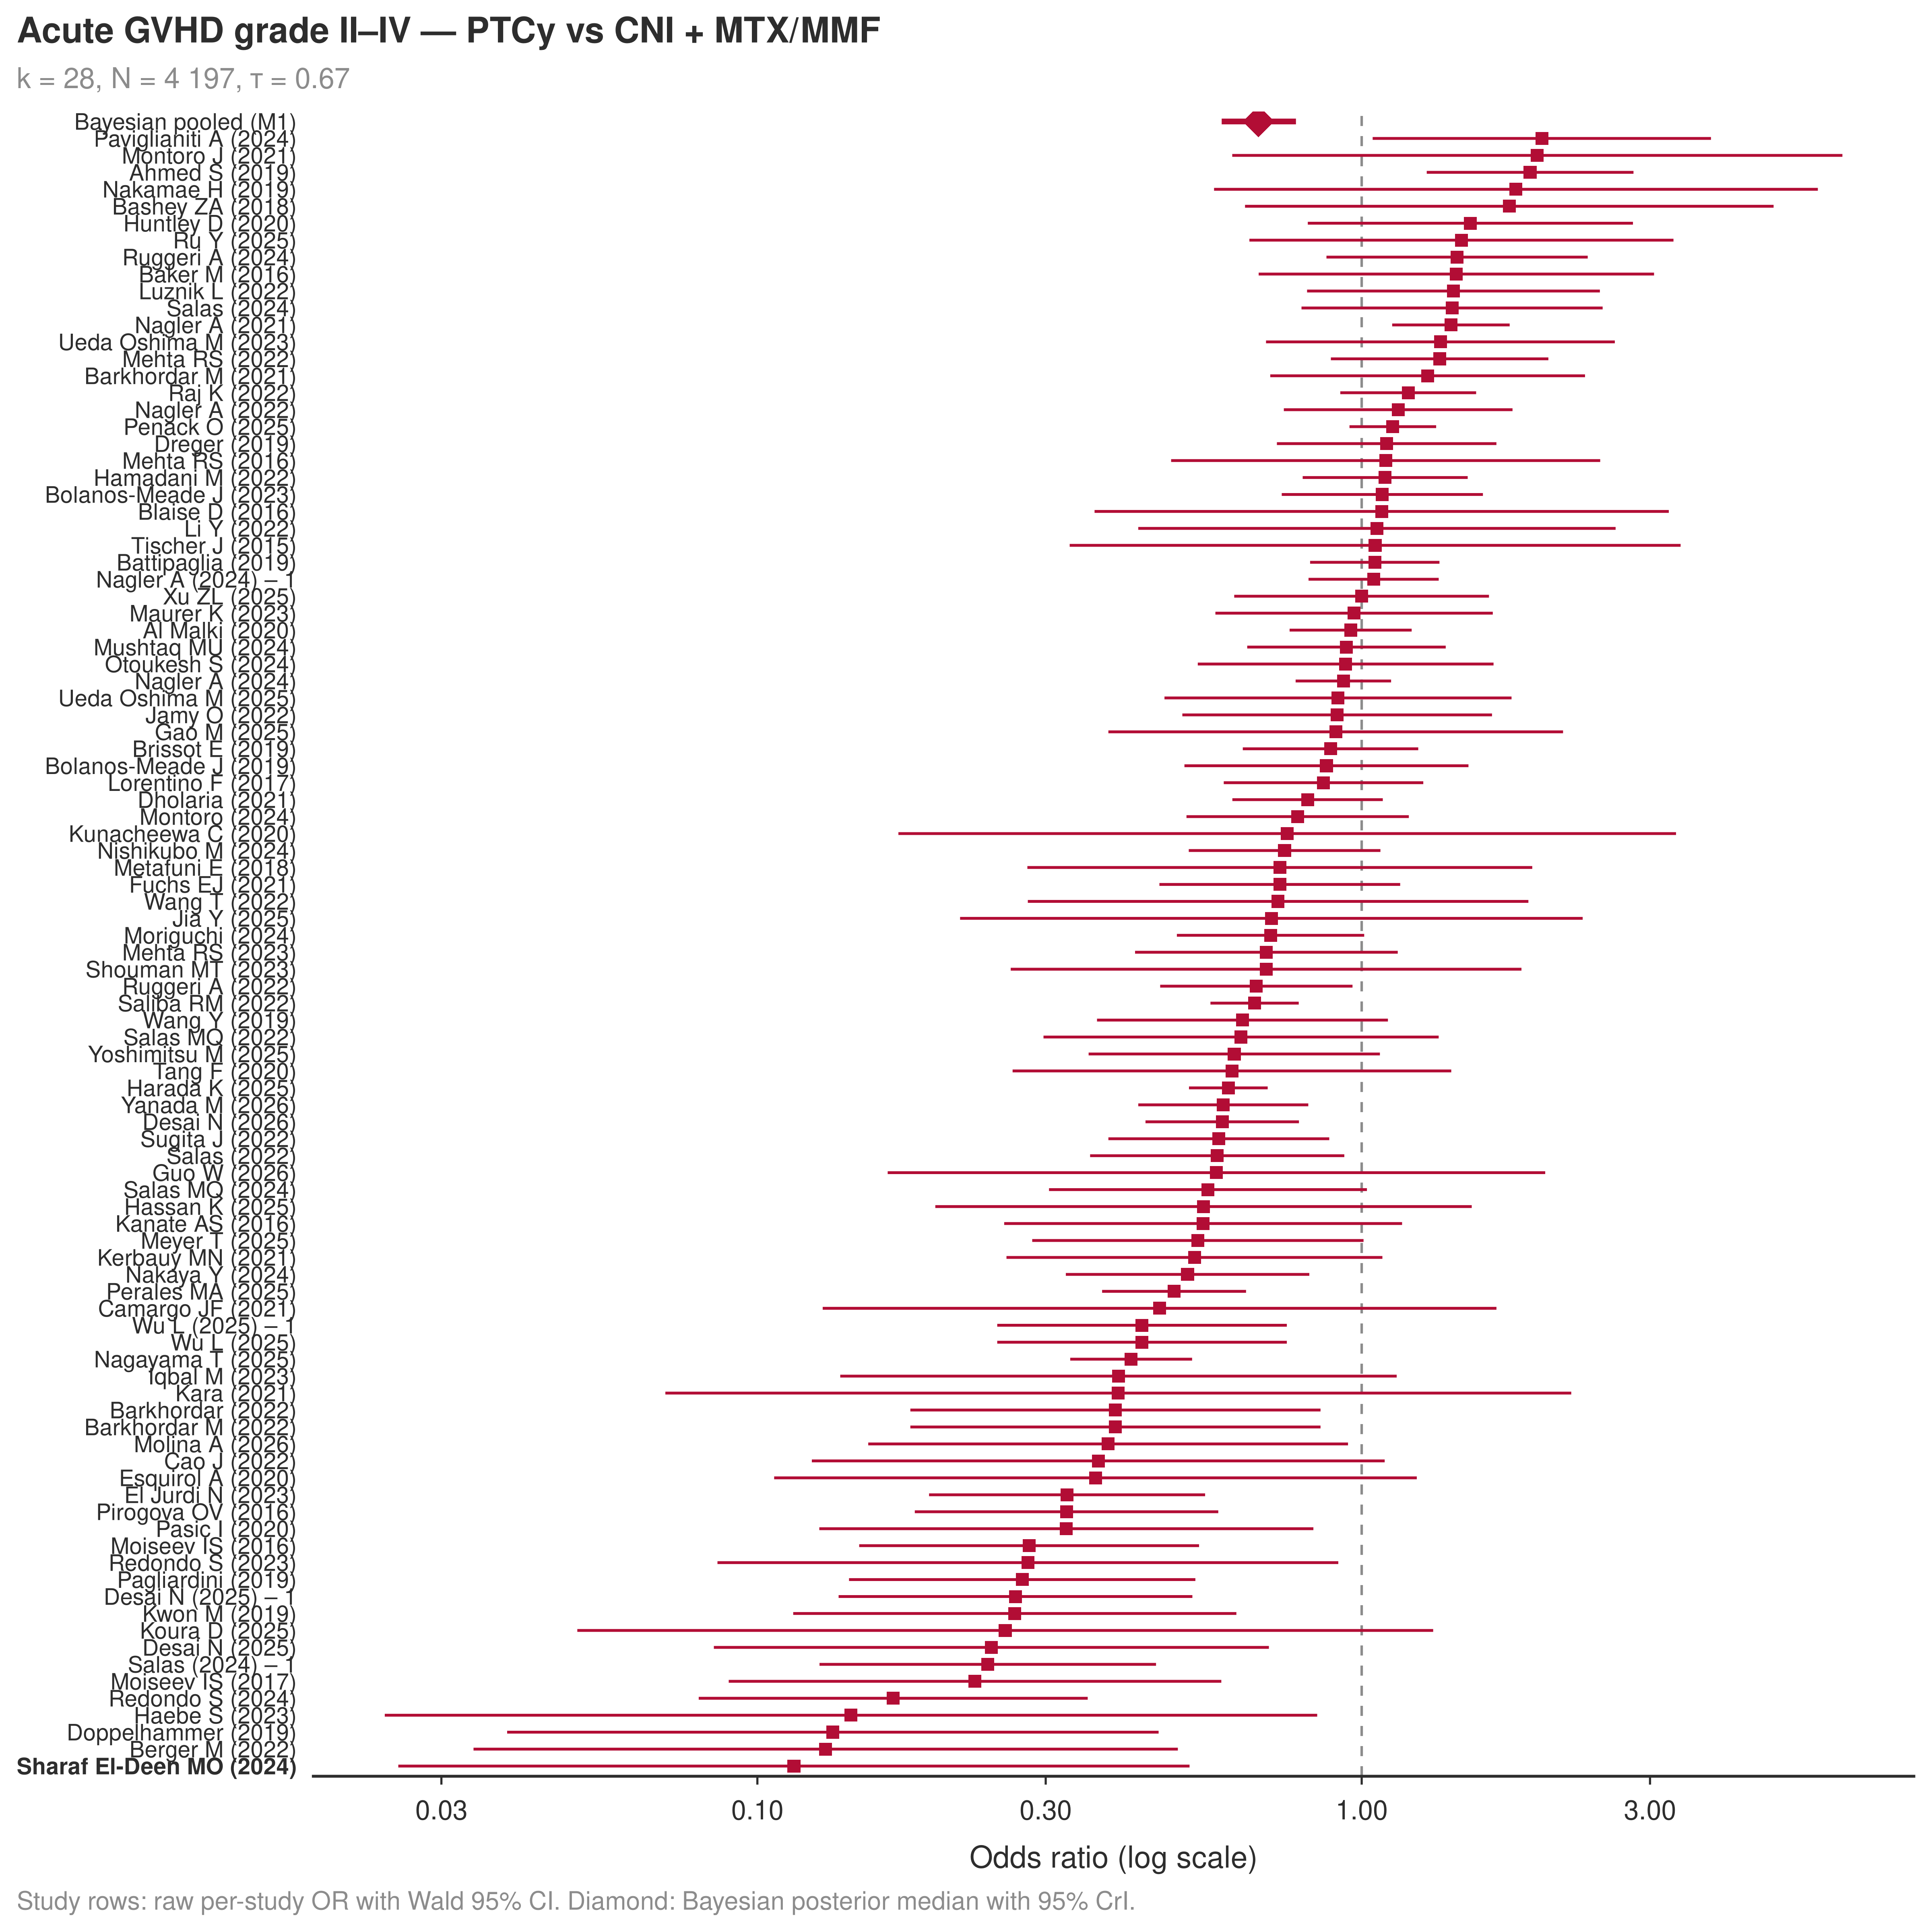

In [ ]:
forest("C1_aGVHD_grade_II_IV.csv", "c1_agvhd",
       "Acute GVHD grade II–IV — PTCy vs CNI + MTX/MMF")


## Exporting the article figures

Two of the article’s figures changed when the manuscript moved to Set B: overall survival (comparison 1) and the comparison 2 panel of the CMV figure. Both are exported here in all three renditions so that `index.qmd` picks up the right one per output format, and so that the figures cannot disagree with table 2.

The remaining article figures — the comparison 1 CMV panel, and the whole of figure 4 (BSI, IFI, BK) — were unaffected by deduplication, so the originals from the analysis repository are kept.

In [ ]:

export <- function(plot, stem, w = 7, h = 9) {
  for (dev in c("png", "pdf", "svg")) {
    ggsave(here("figures", paste0(stem, ".", dev)), plot,
           width = w, height = h, dpi = 300,
           device = dev, bg = "white")
  }
  invisible(stem)
}

export(forest("C1_overall_mortality_OS_event.csv", "c1_os",
              "Overall survival — PTCy vs CNI + MTX/MMF"),
       "Figure2_OS_forest_setB", w = 7, h = 9)


  c1_os <- data_c1_os.csv

ℹ Results may be unexpected or may change in future versions of ggplot2.

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
for 'Wu L (2025) – 1' in 'mbcsToSbcs': - substituted for – (U+2013)

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
conversion failure on 'k = 35, N = 10 133, τ = 0.66' in 'mbcsToSbcs': for τ
(U+03C4)

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
for 'Overall survival — PTCy vs CNI + MTX/MMF' in 'mbcsToSbcs': - substituted
for — (U+2014)

...

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
for 'CMV reactivation — PTCy vs ATG' in 'mbcsToSbcs': - substituted for —
(U+2014)

  c1_cmv <- C1_CMV_any_reactivation.csv

ℹ Results may be unexpected or may change in future versions of ggplot2.

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
conversion failure on 'k = 22, N = 3 328, τ = 0.73' in 'mbcsToSbcs': for τ
(U+03C4)

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
for 'CMV reactivation — PTCy vs CNI + MTX/MMF' in 'mbcsToSbcs': - substituted
for — (U+2014)

## Available analytic datasets

In [ ]:
tibble(file = list.files(here("data", "analytic"), pattern = "[.]csv$")) |>
  filter(!str_starts(file, "_")) |>
  rowwise() |>
  mutate(k = nrow(read_csv(here("data", "analytic", file), show_col_types = FALSE))) |>
  ungroup() |>
  knitr::kable()


  file                                                              k
  ------------------------------------------------------------- -----
  C1_aGVHD_grade_II_IV.csv                                        102
  C1_aGVHD_grade_III_IV.csv                                        84
  C1_BSI_any_pathogen.csv                                          13
  C1_cGVHD_moderate_severe_NIH.csv                                 56
  C1_CMV_any_reactivation.csv                                      22
  C1_IFI_any_EORTC_MSG_proven_probable_combined.csv                 6
  C1_IFI_mold_EORTC_MSG_proven_probable.csv                         4
  C1_infection_related_mortality_IRM_any_cause_infectious.csv      15
  C1_NRM_NRM_overall.csv                                           55
  C1_overall_mortality_OS_event.csv                               108
  C2_aGVHD_grade_II_IV.csv                                         43
  C2_aGVHD_grade_III_IV.csv                                        36
  C2_BSI_any_pathogen.csv                                           5
  C2_cGVHD_moderate_severe_NIH.csv                                 23
  C2_CMV_any_reactivation.csv                                      10
  C2_IFI_any_EORTC_MSG_proven_probable_combined.csv                 3
  C2_IFI_mold_EORTC_MSG_proven_probable.csv                         0
  C2_infection_related_mortality_IRM_any_cause_infectious.csv       8
  C2_NRM_NRM_overall.csv                                           20
  C2_overall_mortality_OS_event.csv                                44
  C3_aGVHD_grade_II_IV.csv                                         17
  C3_aGVHD_grade_III_IV.csv                                        12
  C3_BSI_any_pathogen.csv                                           0
  C3_cGVHD_moderate_severe_NIH.csv                                 13
  C3_CMV_any_reactivation.csv                                       2
  C3_IFI_any_EORTC_MSG_proven_probable_combined.csv                 1
  C3_IFI_mold_EORTC_MSG_proven_probable.csv                         0
  C3_infection_related_mortality_IRM_any_cause_infectious.csv       2
  C3_NRM_NRM_overall.csv                                           10
  C3_overall_mortality_OS_event.csv                                17
